# Language Translation using Simple RNN Encoder-Decoder

A comprehensive tutorial on building a Neural Machine Translation (NMT) system from scratch.

---

## 📚 Table of Contents
1. [Introduction & Theory](#intro)
2. [Sequence-to-Sequence Architecture](#seq2seq)
3. [Special Tokens Explained](#tokens)
4. [Implementation](#implementation)
5. [Training & Evaluation](#training)
6. [References](#references)

---

## <a id='intro'></a>🎯 Introduction

### What is Neural Machine Translation (NMT)?

Neural Machine Translation is the task of translating text from one language (source) to another (target) using neural networks. Unlike traditional phrase-based translation systems, NMT models learn to map entire sentences directly.

### Why is Translation a Sequence-to-Sequence Problem?

Translation is fundamentally a **sequence-to-sequence (seq2seq)** task because:

1. **Variable Length**: Input and output sequences have different lengths
   - "Hello" (1 word) → "Bonjour" (1 word)
   - "How are you?" (3 words) → "Comment allez-vous?" (2 words in French)

2. **Different Word Orders**: Languages have different grammatical structures
   - English: "I love you" (Subject-Verb-Object)
   - French: "Je t'aime" (Subject-Object-Verb)

3. **Context Dependency**: Understanding the entire input is needed before generating output
   - "Bank" can mean financial institution or river side - context matters!

### The Encoder-Decoder Architecture

```
INPUT SENTENCE                    OUTPUT SENTENCE
    ↓                                  ↓
["I", "love", "you"]              ["Je", "t'", "aime"]
    ↓                                  ↓
┌─────────────┐              ┌──────────────┐
│   ENCODER   │──context────→│   DECODER    │
│  (GRU/LSTM) │   vector     │  (GRU/LSTM)  │
└─────────────┘              └──────────────┘
```

**Encoder**: Reads the input sequence and compresses it into a fixed-size context vector (also called thought vector)

**Context Vector**: A dense representation that captures the meaning of the entire input sentence

**Decoder**: Takes the context vector and generates the output sequence word-by-word

---

# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import os
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')

## <a id='tokens'></a>🔤 Special Tokens Explained

### Why Do We Need Special Tokens?

Special tokens are control symbols that help the model understand sequence boundaries and handle edge cases.

### 1. `<PAD>` (Padding Token)

**Purpose**: Make all sequences in a batch the same length

**Why?** Neural networks require fixed-size inputs for batch processing.

**Example:**
```python
Batch of sentences:
  "I am cold"        → [1, 5, 8]           → [1, 5, 8, 0, 0]  # 2 PAD tokens
  "you are smart"    → [2, 6, 9]           → [2, 6, 9, 0, 0]  # 2 PAD tokens  
  "hello world now"  → [10, 11, 12, 13, 14] → [10, 11, 12, 13, 14]  # No padding
                                            ↑ All length 5 now!
```

**Important**: We set `padding_idx=0` in embedding layer so PAD tokens contribute zero to the loss.

### 2. `<SOS>` (Start of Sequence)

**Purpose**: Signal the beginning of a sequence to the decoder

**Why?** The decoder needs an initial input to start generating. We can't use a real word because we don't know what word to start with!

**Example:**
```python
Decoder generation:
  Input: <SOS>  → Output: "Je"
  Input: "Je"   → Output: "t'"
  Input: "t'"   → Output: "aime"
```

### 3. `<EOS>` (End of Sequence)

**Purpose**: Signal when to stop generating

**Why?** The model needs to know when the translation is complete. Without it, the model would generate forever!

**Example:**
```python
Training: "I am cold" + <EOS> → Model learns sentences end
Inference: Model generates "j ai froid" + <EOS> → Stop!
```

### 4. `<UNK>` (Unknown Token)

**Purpose**: Handle words not in vocabulary

**Why?** At test time, you might encounter words you've never seen during training.

**Example:**
```python
Training vocab: {"hello", "world", "I", "am", ...}
Test sentence: "I am supercalifragilisticexpialidocious"
                      ↑ Not in vocab! Replace with <UNK>
Processed: "I am <UNK>"
```

### Token Index Assignment

```python
PAD_TOKEN: 0  # Must be 0 for padding_idx in PyTorch
SOS_TOKEN: 1
EOS_TOKEN: 2
UNK_TOKEN: 3
# Regular words start from index 4 onwards
```

---

## 📖 Key Concepts

### 1. Teacher Forcing

**What?** During training, use the ground truth (correct) word as input to the next decoder step, instead of the predicted word.

**Why?** Speeds up training and stabilizes learning in early stages.

```python
# WITHOUT Teacher Forcing (slower, unstable early on)
Step 1: <SOS>  → Model predicts "Le" (wrong!)
Step 2: "Le"   → Model predicts "xyz" (compound error!)

# WITH Teacher Forcing (faster, stable)
Step 1: <SOS>  → Model predicts "Le" (wrong!)
Step 2: "Je" (ground truth) → Model predicts "t'" (correct!)
```

**Trade-off**: At inference, we don't have ground truth, so the model must use its own predictions (exposure bias).

### 2. Packed Sequences

**What?** A PyTorch optimization to avoid computing on padded elements.

**Why?** Saves computation and memory.

```python
# Without packing: RNN processes PAD tokens (wasteful)
["I", "am", "cold", <PAD>, <PAD>] → RNN processes all 5 steps

# With packing: RNN only processes real tokens
["I", "am", "cold"] → RNN processes only 3 steps
```

### 3. Gradient Clipping

**What?** Limit the magnitude of gradients during backpropagation.

**Why?** Prevents exploding gradients in RNNs.

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

---

## <a id='implementation'></a>💻 Implementation Starts Here

Let's build the Neural Machine Translation system step by step!

In [14]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import Counter
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')

Using device: cpu


## 1. Prepare Sample Data

### Dataset Preparation

For this tutorial, we use a small English-French parallel corpus. In production:
- Use large datasets like **WMT** (millions of sentence pairs)
- Or **Tatoeba** for smaller but high-quality data
- Apply preprocessing: lowercasing, tokenization, removing special chars

**Parallel Corpus**: Sentence pairs where each source sentence has its corresponding translation.

In [15]:
# Sample English-French parallel corpus
# In real applications, load from files (e.g., .txt, .csv)
data_pairs = [
    ("i am cold", "j ai froid"),
    ("i am tired", "je suis fatigue"),
    ("i am hungry", "j ai faim"),
    ("you are smart", "tu es intelligent"),
    ("you are kind", "tu es gentil"),
    ("he is tall", "il est grand"),
    ("she is happy", "elle est heureuse"),
    ("we are friends", "nous sommes amis"),
    ("they are students", "ils sont etudiants"),
    ("i love you", "je t aime"),
    ("hello world", "bonjour monde"),
    ("good morning", "bonjour"),
    ("good night", "bonne nuit"),
    ("thank you", "merci"),
    ("you are welcome", "de rien"),
    ("how are you", "comment allez vous"),
    ("i am fine", "je vais bien"),
    ("what is your name", "quel est votre nom"),
    ("my name is john", "je m appelle john"),
    ("nice to meet you", "enchante"),
]

print(f"Total training pairs: {len(data_pairs)}")
print(f"\nSample translations:")
print("="*60)
for i in range(5):
    src, tgt = data_pairs[i]
    print(f"EN: {src:20} → FR: {tgt}")

Total training pairs: 20

Sample translations:
EN: i am cold            → FR: j ai froid
EN: i am tired           → FR: je suis fatigue
EN: i am hungry          → FR: j ai faim
EN: you are smart        → FR: tu es intelligent
EN: you are kind         → FR: tu es gentil


## 2. Build Vocabulary

### What is a Vocabulary?

A vocabulary is a mapping between words and unique integer indices. Neural networks work with numbers, not text!

### Why Build Separate Vocabularies?

- **Source and target languages have different words**
- **Different vocabulary sizes** (French has different words than English)
- **Independent word-to-index mappings**

### Process:

```
Text: "I love you"  
  ↓ Vocabulary Mapping
Indices: [5, 12, 8]
  ↓ Embedding Layer
Vectors: [[0.2, 0.5, ...], [0.1, 0.8, ...], [0.4, 0.3, ...]]
```

In [16]:
# Define special tokens (control symbols)
PAD_TOKEN = '<PAD>'  # Padding: make sequences same length
SOS_TOKEN = '<SOS>'  # Start of Sequence: decoder start signal
EOS_TOKEN = '<EOS>'  # End of Sequence: when to stop generating
UNK_TOKEN = '<UNK>'  # Unknown: handle out-of-vocabulary words

class Vocabulary:
    """
    Vocabulary class to map words to indices and vice versa.
    
    Attributes:
        word2idx: Dictionary mapping words to integer indices
        idx2word: Dictionary mapping indices back to words
        word_count: Frequency of each word (useful for pruning rare words)
        n_words: Total number of unique words
    """
    def __init__(self, name):
        self.name = name
        # Initialize with special tokens at fixed indices
        self.word2idx = {
            PAD_TOKEN: 0,  # PAD must be 0 for PyTorch padding
            SOS_TOKEN: 1, 
            EOS_TOKEN: 2, 
            UNK_TOKEN: 3
        }
        self.idx2word = {0: PAD_TOKEN, 1: SOS_TOKEN, 2: EOS_TOKEN, 3: UNK_TOKEN}
        self.word_count = {}  # Track word frequencies
        self.n_words = 4  # Start counting from 4 (after special tokens)
    
    def add_sentence(self, sentence):
        """Add all words from a sentence to vocabulary"""
        for word in sentence.split():
            self.add_word(word)
    
    def add_word(self, word):
        """Add a single word to vocabulary"""
        if word not in self.word2idx:
            # New word: assign next available index
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            # Existing word: increment count
            self.word_count[word] += 1

# Create separate vocabularies for source and target languages
source_vocab = Vocabulary('english')
target_vocab = Vocabulary('french')

# Build vocabularies from training data
print("Building vocabularies...")
for src, tgt in data_pairs:
    source_vocab.add_sentence(src)
    target_vocab.add_sentence(tgt)

print(f"\nSource (English) vocabulary size: {source_vocab.n_words}")
print(f"Target (French) vocabulary size: {target_vocab.n_words}")

print(f"\nSample source words: {list(source_vocab.word2idx.keys())[:15]}")
print(f"Sample target words: {list(target_vocab.word2idx.keys())[:15]}")

# Show word-to-index mapping example
print(f"\nWord-to-Index mapping examples:")
for word in ['i', 'am', 'cold']:
    idx = source_vocab.word2idx[word]
    print(f"  '{word}' → {idx}")

Building vocabularies...

Source (English) vocabulary size: 40
Target (French) vocabulary size: 47

Sample source words: ['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'i', 'am', 'cold', 'tired', 'hungry', 'you', 'are', 'smart', 'kind', 'he', 'is']
Sample target words: ['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'j', 'ai', 'froid', 'je', 'suis', 'fatigue', 'faim', 'tu', 'es', 'intelligent', 'gentil']

Word-to-Index mapping examples:
  'i' → 4
  'am' → 5
  'cold' → 6


## 3. Data Preprocessing Functions

### Why Preprocessing?

Transform raw text into tensors that neural networks can process.

### Steps:

1. **Text → Indices**: Convert words to vocabulary indices
2. **Add EOS**: Append end-of-sequence token
3. **Padding**: Make all sequences in batch the same length
4. **Batching**: Group sequences for efficient processing

### Example:

```python
# Raw sentences
"I love you"  →  ["I", "love", "you"]

# Convert to indices
[5, 12, 8]

# Add EOS token
[5, 12, 8, 2]  # 2 is EOS

# Pad to max length (e.g., 6)
[5, 12, 8, 2, 0, 0]  # 0 is PAD
```

In [17]:
def sentence_to_indices(sentence, vocab):
    """
    Convert a sentence (string) to a list of vocabulary indices.
    
    Args:
        sentence: String of space-separated words
        vocab: Vocabulary object
    
    Returns:
        List of integers (word indices)
    """
    # Use .get() with UNK_TOKEN as default for unknown words
    indices = [vocab.word2idx.get(word, vocab.word2idx[UNK_TOKEN]) 
               for word in sentence.split()]
    return indices

def indices_to_sentence(indices, vocab):
    """
    Convert indices back to sentence (for visualization).
    Filter out special tokens for readability.
    """
    special_tokens = [vocab.word2idx[PAD_TOKEN], 
                     vocab.word2idx[SOS_TOKEN], 
                     vocab.word2idx[EOS_TOKEN]]
    words = [vocab.idx2word[idx] for idx in indices 
             if idx not in special_tokens]
    return ' '.join(words)

def prepare_batch(pairs, source_vocab, target_vocab):
    """
    Prepare a batch of sentence pairs for training.
    
    Steps:
    1. Sort by length (required for pack_padded_sequence)
    2. Convert sentences to indices
    3. Add EOS tokens
    4. Pad sequences to same length
    5. Convert to PyTorch tensors
    
    Args:
        pairs: List of (source, target) sentence tuples
        source_vocab: Source language vocabulary
        target_vocab: Target language vocabulary
    
    Returns:
        Tuple of (source_tensor, source_lengths, target_tensor, target_lengths)
    """
    # Sort by source length (descending) - required for packing
    pairs.sort(key=lambda x: len(x[0].split()), reverse=True)
    
    source_sentences = [pair[0] for pair in pairs]
    target_sentences = [pair[1] for pair in pairs]
    
    # Convert sentences to indices
    source_indices = [sentence_to_indices(s, source_vocab) for s in source_sentences]
    target_indices = [sentence_to_indices(s, target_vocab) for s in target_sentences]
    
    # Add EOS token to each sequence
    # This tells the model where sequences end
    source_indices = [idx + [source_vocab.word2idx[EOS_TOKEN]] for idx in source_indices]
    target_indices = [idx + [target_vocab.word2idx[EOS_TOKEN]] for idx in target_indices]
    
    # Record lengths before padding (needed for pack_padded_sequence)
    source_lengths = [len(idx) for idx in source_indices]
    target_lengths = [len(idx) for idx in target_indices]
    
    # Find maximum length in batch
    max_source_len = max(source_lengths)
    max_target_len = max(target_lengths)
    
    # Pad sequences to maximum length
    # Shorter sequences get PAD tokens appended
    padded_source = [idx + [source_vocab.word2idx[PAD_TOKEN]] * (max_source_len - len(idx)) 
                     for idx in source_indices]
    padded_target = [idx + [target_vocab.word2idx[PAD_TOKEN]] * (max_target_len - len(idx)) 
                     for idx in target_indices]
    
    # Convert to PyTorch tensors
    return (torch.LongTensor(padded_source), torch.LongTensor(source_lengths),
            torch.LongTensor(padded_target), torch.LongTensor(target_lengths))

# Test preprocessing with example
print("Testing preprocessing pipeline:\n")
test_sentence = "i am cold"
indices = sentence_to_indices(test_sentence, source_vocab)
print(f"Sentence: '{test_sentence}'")
print(f"Indices: {indices}")
print(f"Back to words: '{indices_to_sentence(indices, source_vocab)}'")

# Test batch preparation
sample_batch = prepare_batch([data_pairs[0]], source_vocab, target_vocab)
print(f"\nBatch shapes:")
print(f"  Source tensor shape: {sample_batch[0].shape}  # (batch_size, max_src_len)")
print(f"  Target tensor shape: {sample_batch[2].shape}  # (batch_size, max_tgt_len)")
print(f"\nSample source sequence (with EOS and PAD):")
print(f"  {sample_batch[0][0].tolist()}")

Testing preprocessing pipeline:

Sentence: 'i am cold'
Indices: [4, 5, 6]
Back to words: 'i am cold'

Batch shapes:
  Source tensor shape: torch.Size([1, 4])  # (batch_size, max_src_len)
  Target tensor shape: torch.Size([1, 4])  # (batch_size, max_tgt_len)

Sample source sequence (with EOS and PAD):
  [4, 5, 6, 2]


## 4. Define Encoder RNN

### What Does the Encoder Do?

The encoder reads the input sentence word-by-word and produces:
1. **Hidden states** at each time step (contextualized representations)
2. **Final hidden state** (context vector - summary of entire input)

### Architecture Components:

```python
Input Sequence → Embedding → Dropout → GRU → Outputs & Hidden State
```

- **Embedding Layer**: Converts word indices to dense vectors (learnable)
- **Dropout**: Regularization to prevent overfitting
- **GRU**: Gated Recurrent Unit - processes sequence sequentially
- **pack_padded_sequence**: Optimization to skip PAD tokens

### Why pack_padded_sequence?

Without packing, RNN wastes computation on PAD tokens:
```
Sentence: ["I", "am", "cold", PAD, PAD]
RNN processes all 5 steps (wasteful!)
```

With packing, RNN only processes real tokens:
```
Packed: ["I", "am", "cold"] → RNN processes 3 steps (efficient!)
```

In [18]:
class EncoderRNN(nn.Module):
    """
    Encoder RNN that processes input sequence and produces context vector.
    
    Architecture:
        Input → Embedding → Dropout → GRU → Context Vector
    
    Args:
        vocab_size: Size of source vocabulary
        embedding_dim: Dimension of word embeddings (e.g., 256)
        hidden_dim: Dimension of GRU hidden state (e.g., 512)
        num_layers: Number of stacked GRU layers (e.g., 2)
        dropout: Dropout probability for regularization
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Embedding layer: converts word indices to dense vectors
        # padding_idx=0 means PAD tokens get zero vector (not learned)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # GRU (Gated Recurrent Unit)
        # - Takes embedded words as input
        # - Maintains hidden state across time steps
        # - batch_first=True means input shape is (batch, seq_len, embed_dim)
        self.rnn = nn.GRU(
            embedding_dim, 
            hidden_dim, 
            num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0  # Dropout between layers
        )
        
        # Dropout for regularization (applied to embeddings)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, input_seq, input_lengths):
        """
        Forward pass through encoder.
        
        Args:
            input_seq: (batch_size, max_seq_len) - padded input indices
            input_lengths: (batch_size,) - actual lengths before padding
        
        Returns:
            outputs: (batch_size, max_seq_len, hidden_dim) - hidden states at each step
            hidden: (num_layers, batch_size, hidden_dim) - final hidden state (context!)
        """
        # 1. Embed input words
        embedded = self.embedding(input_seq)  # (batch, seq_len, embed_dim)
        embedded = self.dropout(embedded)
        
        # 2. Pack padded sequences (optimization)
        # This tells RNN to skip computation on PAD tokens
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, 
            input_lengths.cpu(),  # Lengths must be on CPU
            batch_first=True, 
            enforce_sorted=True  # We sorted in prepare_batch()
        )
        
        # 3. Forward through GRU
        # outputs: hidden state at each time step
        # hidden: final hidden state (this is our context vector!)
        outputs, hidden = self.rnn(packed)
        
        # 4. Unpack (convert back to padded format)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        
        return outputs, hidden

# Initialize encoder
encoder = EncoderRNN(
    vocab_size=source_vocab.n_words,
    embedding_dim=256,
    hidden_dim=512,
    num_layers=2,
    dropout=0.1
)

print("Encoder Architecture:")
print(encoder)
print(f"\nTotal parameters: {sum(p.numel() for p in encoder.parameters()):,}")

# Calculate parameter breakdown
print("\nParameter breakdown:")
for name, param in encoder.named_parameters():
    print(f"  {name:20} {param.shape} = {param.numel():,} params")

Encoder Architecture:
EncoderRNN(
  (embedding): Embedding(40, 256, padding_idx=0)
  (rnn): GRU(256, 512, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
)

Total parameters: 2,768,896

Parameter breakdown:
  embedding.weight     torch.Size([40, 256]) = 10,240 params
  rnn.weight_ih_l0     torch.Size([1536, 256]) = 393,216 params
  rnn.weight_hh_l0     torch.Size([1536, 512]) = 786,432 params
  rnn.bias_ih_l0       torch.Size([1536]) = 1,536 params
  rnn.bias_hh_l0       torch.Size([1536]) = 1,536 params
  rnn.weight_ih_l1     torch.Size([1536, 512]) = 786,432 params
  rnn.weight_hh_l1     torch.Size([1536, 512]) = 786,432 params
  rnn.bias_ih_l1       torch.Size([1536]) = 1,536 params
  rnn.bias_hh_l1       torch.Size([1536]) = 1,536 params


## 5. Define Decoder RNN

### What Does the Decoder Do?

The decoder generates the output sequence one word at a time:
1. **Initialization**: Receives context vector from encoder
2. **Auto-regressive Generation**: Uses previous output as next input
3. **Stopping**: Generates until EOS token

### Architecture Components:

```python
Context Vector → [Loop] → Current Word → Embedding → GRU → Projection → Next Word
                   ↑________________________________________________|
```

### Generation Process:

```python
Step 0: Input=<SOS>, Hidden=context  → Output="Je"
Step 1: Input="Je",  Hidden=h1       → Output="t'"
Step 2: Input="t'",  Hidden=h2       → Output="aime"
Step 3: Input="aime", Hidden=h3      → Output=<EOS> (stop!)
```

### Why Linear Layer (fc)?

GRU outputs hidden state (512 dims), but we need probabilities over vocabulary (vocab_size). Linear layer projects hidden state to vocabulary space.

In [19]:
class DecoderRNN(nn.Module):
    """
    Decoder RNN that generates output sequence word-by-word.
    
    Architecture:
        Input Word → Embedding → Dropout → GRU → Linear → Output Distribution
    
    Args:
        vocab_size: Size of target vocabulary
        embedding_dim: Dimension of word embeddings
        hidden_dim: Dimension of GRU hidden state (must match encoder!)
        num_layers: Number of GRU layers (must match encoder!)
        dropout: Dropout probability
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.1):
        super(DecoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.vocab_size = vocab_size
        
        # Embedding layer for target language
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # GRU (same architecture as encoder for symmetry)
        self.rnn = nn.GRU(
            embedding_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Linear layer: projects hidden state to vocabulary space
        # Output: unnormalized scores (logits) for each word in vocabulary
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, input_token, hidden):
        """
        Generate next word given current word and hidden state.
        
        Note: Decoder processes ONE token at a time (auto-regressive).
        
        Args:
            input_token: (batch_size, 1) - current word index
            hidden: (num_layers, batch_size, hidden_dim) - previous hidden state
        
        Returns:
            output: (batch_size, vocab_size) - scores for next word
            hidden: (num_layers, batch_size, hidden_dim) - updated hidden state
        """
        # 1. Embed current input token
        embedded = self.embedding(input_token)  # (batch, 1, embed_dim)
        embedded = self.dropout(embedded)
        
        # 2. Forward through GRU
        # hidden input: previous hidden state (maintains context)
        # hidden output: updated hidden state (passed to next step)
        output, hidden = self.rnn(embedded, hidden)
        
        # 3. Project to vocabulary space
        # Remove sequence dimension: (batch, 1, hidden) → (batch, hidden)
        output = output.squeeze(1)
        
        # Linear projection: (batch, hidden) → (batch, vocab_size)
        # Output: unnormalized scores (logits) for each word
        output = self.fc(output)
        
        return output, hidden

# Initialize decoder
decoder = DecoderRNN(
    vocab_size=target_vocab.n_words,
    embedding_dim=256,
    hidden_dim=512,
    num_layers=2,
    dropout=0.1
)

print("Decoder Architecture:")
print(decoder)
print(f"\nTotal parameters: {sum(p.numel() for p in decoder.parameters()):,}")

# Parameter breakdown
print("\nParameter breakdown:")
for name, param in decoder.named_parameters():
    print(f"  {name:20} {param.shape} = {param.numel():,} params")

total_params = sum(p.numel() for p in encoder.parameters()) + sum(p.numel() for p in decoder.parameters())
print(f"\n{'='*60}")
print(f"Total model parameters: {total_params:,}")
print(f"{'='*60}")

Decoder Architecture:
DecoderRNN(
  (embedding): Embedding(47, 256, padding_idx=0)
  (rnn): GRU(256, 512, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=512, out_features=47, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

Total parameters: 2,794,799

Parameter breakdown:
  embedding.weight     torch.Size([47, 256]) = 12,032 params
  rnn.weight_ih_l0     torch.Size([1536, 256]) = 393,216 params
  rnn.weight_hh_l0     torch.Size([1536, 512]) = 786,432 params
  rnn.bias_ih_l0       torch.Size([1536]) = 1,536 params
  rnn.bias_hh_l0       torch.Size([1536]) = 1,536 params
  rnn.weight_ih_l1     torch.Size([1536, 512]) = 786,432 params
  rnn.weight_hh_l1     torch.Size([1536, 512]) = 786,432 params
  rnn.bias_ih_l1       torch.Size([1536]) = 1,536 params
  rnn.bias_hh_l1       torch.Size([1536]) = 1,536 params
  fc.weight            torch.Size([47, 512]) = 24,064 params
  fc.bias              torch.Size([47]) = 47 params

Total model parameters: 5,563,695


## 6. Training Function

### Training Process:

1. **Forward pass through encoder** → Get context vector
2. **Initialize decoder** with context vector and SOS token
3. **Loop through target sequence**:
   - Generate next word
   - Compare with ground truth (calculate loss)
   - Use teacher forcing or own prediction for next input
4. **Backpropagation** → Update weights

### Teacher Forcing:

**With Teacher Forcing (ratio=1.0)**:
```
Decoder input at step t = ground truth word at t-1
Faster training, more stable
```

**Without Teacher Forcing (ratio=0.0)**:
```
Decoder input at step t = predicted word at t-1
Slower training, matches inference behavior
```

**Scheduled Sampling (ratio=0.5)**:
```
50% of time: use ground truth
50% of time: use prediction
Balances stability and realism
```

In [20]:
def train_step(encoder, decoder, source_batch, source_lengths, target_batch, target_lengths, 
               encoder_optimizer, decoder_optimizer, criterion, device, teacher_forcing_ratio=0.5):
    """
    Single training step (forward + backward pass).
    
    Args:
        encoder, decoder: Model instances
        source_batch: (batch_size, max_src_len) - source sequences
        source_lengths: (batch_size,) - actual source lengths
        target_batch: (batch_size, max_tgt_len) - target sequences
        target_lengths: (batch_size,) - actual target lengths
        encoder_optimizer, decoder_optimizer: Optimizers for each model
        criterion: Loss function (CrossEntropyLoss)
        device: 'cuda' or 'cpu'
        teacher_forcing_ratio: Probability of using teacher forcing
    
    Returns:
        Average loss for this batch
    """
    # Reset gradients
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    
    # Move data to device (GPU/CPU)
    source_batch = source_batch.to(device)
    target_batch = target_batch.to(device)
    source_lengths = source_lengths.to(device)
    target_lengths = target_lengths.to(device)
    
    batch_size = source_batch.size(0)
    max_target_len = target_batch.size(1)
    
    loss = 0
    
    # ===== ENCODER =====
    # Process entire source sequence at once
    encoder_outputs, encoder_hidden = encoder(source_batch, source_lengths)
    # encoder_hidden is our context vector!
    
    # ===== DECODER INITIALIZATION =====
    # Start with SOS token for all sequences in batch
    decoder_input = torch.LongTensor([[target_vocab.word2idx[SOS_TOKEN]]] * batch_size).to(device)
    
    # Initialize decoder hidden state with encoder's final hidden state (context vector)
    decoder_hidden = encoder_hidden
    
    # Decide whether to use teacher forcing for this batch
    use_teacher_forcing = random.random() < teacher_forcing_ratio
    
    # ===== DECODER LOOP =====
    # Generate sequence one word at a time
    for t in range(max_target_len):
        # Generate next word
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
        # decoder_output: (batch_size, vocab_size) - scores for each word
        
        # Get ground truth token at position t
        target_token = target_batch[:, t]
        
        # Calculate loss (compare predicted scores with ground truth)
        loss += criterion(decoder_output, target_token)
        
        # Prepare input for next step
        if use_teacher_forcing:
            # Teacher forcing: use ground truth as next input
            decoder_input = target_token.unsqueeze(1)  # (batch, 1)
        else:
            # No teacher forcing: use model's prediction as next input
            _, topi = decoder_output.topk(1)  # Get index of highest scoring word
            decoder_input = topi.detach()  # Detach from graph to save memory
    
    # ===== BACKPROPAGATION =====
    loss.backward()
    
    # Gradient clipping (prevent exploding gradients in RNNs)
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
    
    # Update weights
    encoder_optimizer.step()
    decoder_optimizer.step()
    
    # Return average loss per token
    return loss.item() / max_target_len

## 7. Evaluation Function

### Inference (Testing) Process:

Different from training - no teacher forcing, no ground truth!

```python
1. Encode input sentence → context vector
2. Start with <SOS> token
3. Loop:
   - Generate next word
   - If word is <EOS>, stop
   - Otherwise, use generated word as next input
4. Return generated sequence
```

### Greedy Decoding:

At each step, choose the word with highest probability (greedy). Simple but not optimal.

**Better alternatives** (not implemented here):
- **Beam Search**: Keep top-k candidates at each step
- **Sampling**: Sample from probability distribution

In [21]:
def evaluate(encoder, decoder, sentence, source_vocab, target_vocab, device, max_length=20):
    """
    Translate a single sentence (inference mode).
    
    No teacher forcing - model uses its own predictions!
    
    Args:
        encoder, decoder: Trained models
        sentence: Source sentence (string)
        source_vocab, target_vocab: Vocabulary objects
        device: 'cuda' or 'cpu'
        max_length: Maximum output length (safety limit)
    
    Returns:
        Translated sentence (string)
    """
    # Set models to evaluation mode (disables dropout)
    encoder.eval()
    decoder.eval()
    
    with torch.no_grad():  # Disable gradient computation (saves memory)
        # ===== PREPARE INPUT =====
        input_indices = sentence_to_indices(sentence, source_vocab)
        input_indices.append(source_vocab.word2idx[EOS_TOKEN])  # Add EOS
        
        # Convert to tensor: (1, seq_len) - batch size = 1
        input_tensor = torch.LongTensor(input_indices).unsqueeze(0).to(device)
        input_length = torch.LongTensor([len(input_indices)]).to(device)
        
        # ===== ENCODE =====
        encoder_outputs, encoder_hidden = encoder(input_tensor, input_length)
        
        # ===== DECODE =====
        # Start with SOS token
        decoder_input = torch.LongTensor([[target_vocab.word2idx[SOS_TOKEN]]]).to(device)
        decoder_hidden = encoder_hidden
        
        decoded_words = []
        
        # Generate words one at a time
        for _ in range(max_length):
            # Generate next word
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            # decoder_output: (1, vocab_size)
            
            # Get most likely word (greedy decoding)
            _, topi = decoder_output.topk(1)  # topi: (1, 1)
            token_idx = topi.item()
            
            # Check if we should stop
            if token_idx == target_vocab.word2idx[EOS_TOKEN]:
                break  # Stop generation
            else:
                # Add word to output
                decoded_words.append(target_vocab.idx2word[token_idx])
            
            # Use generated word as next input
            decoder_input = topi.detach()
        
        # Join words into sentence
        return ' '.join(decoded_words)

def evaluate_randomly(encoder, decoder, pairs, source_vocab, target_vocab, device, n=5):
    """
    Evaluate on n random examples from dataset.
    """
    for _ in range(n):
        pair = random.choice(pairs)
        source_sentence = pair[0]
        target_sentence = pair[1]
        
        translation = evaluate(encoder, decoder, source_sentence, source_vocab, target_vocab, device)
        
        print(f"Source:     {source_sentence}")
        print(f"Target:     {target_sentence}")
        print(f"Predicted:  {translation}")
        print()

## <a id='training'></a>8. Train the Model

### Hyperparameters Explained:

- **EMBEDDING_DIM (256)**: Size of word vectors. Larger = more expressive but slower.
- **HIDDEN_DIM (512)**: Size of GRU hidden state. Larger = more memory capacity.
- **NUM_LAYERS (2)**: Stack multiple GRU layers. Deeper = more capacity but harder to train.
- **DROPOUT (0.1)**: Randomly drop 10% of connections during training (regularization).
- **LEARNING_RATE (0.001)**: Step size for gradient descent. Too high = unstable, too low = slow.
- **TEACHER_FORCING_RATIO (0.5)**: Use ground truth 50% of time during training.
- **NUM_EPOCHS (2000)**: Number of training iterations. Small dataset needs more epochs.

### Loss Function:

**CrossEntropyLoss**: Measures how well predicted word distribution matches ground truth.
- Low loss = model is confident and correct
- High loss = model is uncertain or wrong
- `ignore_index=0` means don't calculate loss on PAD tokens

In [22]:
# ===== HYPERPARAMETERS =====
EMBEDDING_DIM = 256        # Word embedding dimension
HIDDEN_DIM = 512           # GRU hidden state dimension
NUM_LAYERS = 2             # Number of stacked GRU layers
DROPOUT = 0.1              # Dropout probability
LEARNING_RATE = 0.001      # Learning rate for Adam optimizer
NUM_EPOCHS = 2000          # Number of training epochs
BATCH_SIZE = 4             # Number of sentences per batch
TEACHER_FORCING_RATIO = 0.5  # Probability of using teacher forcing
PRINT_EVERY = 200          # Print progress every N epochs

# ===== INITIALIZE MODELS =====
encoder = EncoderRNN(
    vocab_size=source_vocab.n_words,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

decoder = DecoderRNN(
    vocab_size=target_vocab.n_words,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

# ===== OPTIMIZERS =====
# Adam: Adaptive learning rate optimizer (good default choice)
encoder_optimizer = optim.Adam(encoder.parameters(), lr=LEARNING_RATE)
decoder_optimizer = optim.Adam(decoder.parameters(), lr=LEARNING_RATE)

# ===== LOSS FUNCTION =====
# CrossEntropyLoss: standard for classification tasks
# ignore_index=0: don't calculate loss on PAD tokens
criterion = nn.CrossEntropyLoss(ignore_index=target_vocab.word2idx[PAD_TOKEN])

print("Training Configuration:")
print(f"  Device: {device}")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Num layers: {NUM_LAYERS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Teacher forcing ratio: {TEACHER_FORCING_RATIO}")
print(f"\nTotal parameters: {sum(p.numel() for p in encoder.parameters()) + sum(p.numel() for p in decoder.parameters()):,}")
print("\nStarting training...\n")
print("="*70)

# ===== TRAINING LOOP =====
losses = []  # Track loss over time

for epoch in range(1, NUM_EPOCHS + 1):
    # Set models to training mode (enables dropout)
    encoder.train()
    decoder.train()
    
    # Sample random batch from training data
    batch_pairs = random.sample(data_pairs, min(BATCH_SIZE, len(data_pairs)))
    
    # Prepare batch (convert to tensors, pad, etc.)
    source_batch, source_lengths, target_batch, target_lengths = prepare_batch(
        batch_pairs, source_vocab, target_vocab
    )
    
    # Training step (forward + backward pass)
    loss = train_step(
        encoder, decoder, 
        source_batch, source_lengths, 
        target_batch, target_lengths,
        encoder_optimizer, decoder_optimizer, 
        criterion, device, 
        TEACHER_FORCING_RATIO
    )
    
    losses.append(loss)
    
    # Print progress periodically
    if epoch % PRINT_EVERY == 0:
        avg_loss = sum(losses[-PRINT_EVERY:]) / PRINT_EVERY
        print(f"Epoch {epoch}/{NUM_EPOCHS} | Avg Loss: {avg_loss:.4f}")
        print("-" * 70)
        
        # Show sample translations
        evaluate_randomly(encoder, decoder, data_pairs, source_vocab, target_vocab, device, n=3)
        print("=" * 70)

print("\n✓ Training complete!")

Training Configuration:
  Device: cpu
  Embedding dim: 256
  Hidden dim: 512
  Num layers: 2
  Learning rate: 0.001
  Batch size: 4
  Epochs: 2000
  Teacher forcing ratio: 0.5

Total parameters: 5,563,695

Starting training...

Epoch 200/2000 | Avg Loss: 0.4348
----------------------------------------------------------------------
Source:     i love you
Target:     je t aime
Predicted:  je t aime

Source:     i am cold
Target:     j ai froid
Predicted:  j ai froid

Source:     good night
Target:     bonne nuit
Predicted:  bonne nuit

Epoch 400/2000 | Avg Loss: 0.0004
----------------------------------------------------------------------
Source:     she is happy
Target:     elle est heureuse
Predicted:  elle est heureuse

Source:     she is happy
Target:     elle est heureuse
Predicted:  elle est heureuse

Source:     what is your name
Target:     quel est votre nom
Predicted:  quel est votre nom

Epoch 600/2000 | Avg Loss: 0.0002
--------------------------------------------------------

## 9. Plot Training Loss

### Loss Curve Interpretation:

- **Decreasing loss**: Model is learning ✓
- **Plateauing loss**: Model has converged
- **Increasing loss**: Something is wrong (learning rate too high, bug, etc.)
- **Oscillating loss**: Normal for small batches, smooth with moving average

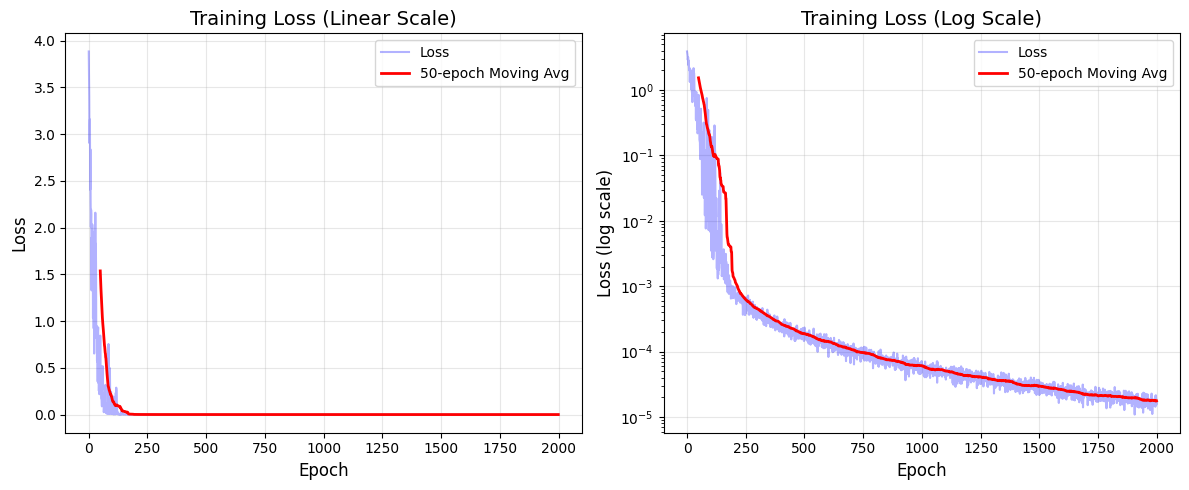


Training Statistics:
  Initial loss: 3.8831
  Final loss: 0.0000
  Best loss: 0.0000 (epoch 1907)
  Improvement: 100.0%


In [23]:
plt.figure(figsize=(12, 5))

# ===== SUBPLOT 1: Linear Scale =====
plt.subplot(1, 2, 1)
plt.plot(losses, alpha=0.3, label='Loss', color='blue')

# Plot moving average for smoother trend
window = 50
if len(losses) >= window:
    moving_avg = np.convolve(losses, np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(losses)), moving_avg, 
             label=f'{window}-epoch Moving Avg', linewidth=2, color='red')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Loss (Linear Scale)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# ===== SUBPLOT 2: Log Scale =====
plt.subplot(1, 2, 2)
plt.plot(losses, alpha=0.3, label='Loss', color='blue')
if len(losses) >= window:
    plt.plot(range(window-1, len(losses)), moving_avg, 
             label=f'{window}-epoch Moving Avg', linewidth=2, color='red')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (log scale)', fontsize=12)
plt.title('Training Loss (Log Scale)', fontsize=14)
plt.yscale('log')  # Log scale better shows early rapid improvement
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"\nTraining Statistics:")
print(f"  Initial loss: {losses[0]:.4f}")
print(f"  Final loss: {losses[-1]:.4f}")
print(f"  Best loss: {min(losses):.4f} (epoch {losses.index(min(losses))+1})")
print(f"  Improvement: {((losses[0] - losses[-1])/losses[0]*100):.1f}%")

## 10. Test the Model

### Evaluation Metrics:

- **Exact Match Accuracy**: Percentage of perfect translations (strict)
- **BLEU Score**: Measures n-gram overlap (standard MT metric)
- **Human Evaluation**: Best but expensive

For this small dataset, we use exact match accuracy.

In [24]:
# Test on all training examples
print("Testing on all training examples:\n")
print("="*90)

encoder.eval()
decoder.eval()

correct = 0
total = len(data_pairs)

for source, target in data_pairs:
    translation = evaluate(encoder, decoder, source, source_vocab, target_vocab, device)
    is_correct = translation == target
    if is_correct:
        correct += 1
    
    # Visual indicator
    status = "✓" if is_correct else "✗"
    print(f"{status} EN: {source:30} | Target: {target:25} | Predicted: {translation}")

print("="*90)
accuracy = (correct / total) * 100
print(f"\nExact Match Accuracy: {correct}/{total} ({accuracy:.1f}%)")

if accuracy >= 90:
    print("\n🎉 Excellent! Model has learned the training set very well.")
elif accuracy >= 70:
    print("\n👍 Good! Model is learning. Try training longer for better results.")
else:
    print("\n⚠️ Model needs more training. Consider increasing epochs or adjusting hyperparameters.")

Testing on all training examples:

✓ EN: i am cold                      | Target: j ai froid                | Predicted: j ai froid
✓ EN: i am tired                     | Target: je suis fatigue           | Predicted: je suis fatigue
✓ EN: i am hungry                    | Target: j ai faim                 | Predicted: j ai faim
✓ EN: you are smart                  | Target: tu es intelligent         | Predicted: tu es intelligent
✓ EN: you are kind                   | Target: tu es gentil              | Predicted: tu es gentil
✓ EN: he is tall                     | Target: il est grand              | Predicted: il est grand
✓ EN: she is happy                   | Target: elle est heureuse         | Predicted: elle est heureuse
✓ EN: we are friends                 | Target: nous sommes amis          | Predicted: nous sommes amis
✓ EN: they are students              | Target: ils sont etudiants        | Predicted: ils sont etudiants
✓ EN: i love you                     | Target: je t aime

## 11. Interactive Translation

Now you can translate any English sentence to French!

**Note**: Model only knows words from training data. Unknown words become `<UNK>`.

In [27]:
def translate(sentence):
    """Translate a sentence from English to French"""
    encoder.eval()
    decoder.eval()
    
    sentence = sentence.lower().strip()
    translation = evaluate(encoder, decoder, sentence, source_vocab, target_vocab, device)
    
    print(f"English: {sentence}")
    print(f"French:  {translation}")
    return translation

# Try some translations
print("\nTranslation Examples:\n")
print("="*50)

test_sentences = [
    "i am cold",
    "you are smart",
    "hello world",
    "thank you",
    "wait"
]

for sent in test_sentences:
    translate(sent)
    print()

print("="*50)
print("\nTry your own sentence:")
print("Example: translate('i am happy')")


Translation Examples:

English: i am cold
French:  j ai froid

English: you are smart
French:  tu es intelligent

English: hello world
French:  bonjour monde

English: thank you
French:  merci

English: wait
French:  bonjour monde


Try your own sentence:
Example: translate('i am happy')


## 12. Save the Model

### What to Save:

- **Model weights**: Learned parameters
- **Vocabularies**: Word-to-index mappings (essential!)
- **Hyperparameters**: To reconstruct model architecture
- **Optimizer state**: To resume training later (optional)

In [28]:
# Save complete checkpoint
checkpoint = {
    # Model weights
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    
    # Optimizer states (to resume training)
    'encoder_optimizer': encoder_optimizer.state_dict(),
    'decoder_optimizer': decoder_optimizer.state_dict(),
    
    # Vocabularies (CRITICAL - needed for inference!)
    'source_vocab': source_vocab,
    'target_vocab': target_vocab,
    
    # Hyperparameters (to reconstruct architecture)
    'hyperparameters': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT
    },
    
    # Metadata
    'epoch': NUM_EPOCHS,
    'loss_history': losses
}

save_path = 'translator_rnn_model.pth'
torch.save(checkpoint, save_path)
print(f"✓ Model saved as '{save_path}'")
print(f"  File size: {os.path.getsize(save_path) / 1024:.1f} KB")

✓ Model saved as 'translator_rnn_model.pth'
  File size: 65244.0 KB


## 13. Load Model (For Future Use)

How to load the model in a new notebook/script.

In [ ]:
# # Uncomment to test loading
# 
# # Load checkpoint
# checkpoint = torch.load('translator_rnn_model.pth')
# 
# # Recreate models with saved hyperparameters
# loaded_encoder = EncoderRNN(
#     vocab_size=checkpoint['source_vocab'].n_words,
#     embedding_dim=checkpoint['hyperparameters']['embedding_dim'],
#     hidden_dim=checkpoint['hyperparameters']['hidden_dim'],
#     num_layers=checkpoint['hyperparameters']['num_layers'],
#     dropout=checkpoint['hyperparameters']['dropout']
# ).to(device)
# 
# loaded_decoder = DecoderRNN(
#     vocab_size=checkpoint['target_vocab'].n_words,
#     embedding_dim=checkpoint['hyperparameters']['embedding_dim'],
#     hidden_dim=checkpoint['hyperparameters']['hidden_dim'],
#     num_layers=checkpoint['hyperparameters']['num_layers'],
#     dropout=checkpoint['hyperparameters']['dropout']
# ).to(device)
# 
# # Load weights
# loaded_encoder.load_state_dict(checkpoint['encoder_state_dict'])
# loaded_decoder.load_state_dict(checkpoint['decoder_state_dict'])
# 
# # Load vocabularies
# source_vocab = checkpoint['source_vocab']
# target_vocab = checkpoint['target_vocab']
# 
# print("✓ Model loaded successfully!")
# 
# # Now you can use loaded_encoder and loaded_decoder for translation
# test_sentence = "i am cold"
# translation = evaluate(loaded_encoder, loaded_decoder, test_sentence, 
#                       source_vocab, target_vocab, device)
# print(f"{test_sentence} → {translation}")

---

## 📚 Summary & Key Takeaways

### What We Built:

1. ✅ **Encoder-Decoder RNN Architecture** (basic seq2seq)
   - Encoder: GRU that processes source language
   - Decoder: GRU that generates target language
   - Context vector: Bridge between encoder and decoder

2. ✅ **Special Tokens System**:
   - `<PAD>`: Batch padding
   - `<SOS>`: Start signal for decoder
   - `<EOS>`: Stop signal
   - `<UNK>`: Handle unknown words

3. ✅ **Training Techniques**:
   - Teacher forcing for faster convergence
   - Packed sequences for efficiency
   - Gradient clipping for stability

### Limitations of This Approach:

1. **Information Bottleneck**: 
   - Entire source sentence compressed into single context vector
   - Long sentences lose information

2. **No Alignment**: 
   - Model can't focus on relevant parts of input
   - All words weighted equally

3. **Sequential Processing**: 
   - Can't parallelize (slow for long sequences)

### How to Improve:

1. **Add Attention Mechanism** ⭐
   - Allows decoder to focus on relevant input words
   - Bahdanau Attention (2014) or Luong Attention (2015)
   - Major improvement in translation quality!

2. **Use Bidirectional Encoder**
   - Process input in both directions (forward + backward)
   - Better context understanding

3. **Implement Beam Search**
   - Instead of greedy decoding, keep top-k candidates
   - Better translation quality

4. **Use Larger Dataset**
   - WMT datasets (millions of sentence pairs)
   - Tatoeba for many language pairs

5. **Try LSTM or Transformer**
   - LSTM: Better long-term memory
   - Transformer: State-of-the-art (BERT, GPT, etc.)

### Important Note:

**This IS a seq2seq model!** Translation inherently requires:
- Encoder to understand source
- Decoder to generate target
- Some way to pass information between them (context vector)

What you can avoid:
- ❌ Attention mechanisms
- ❌ Transformer architecture
- ❌ Pre-trained models

But encoder-decoder structure is **fundamental** to translation.

---

## <a id='references'></a>📖 References & Further Reading

### Foundational Papers:

1. **Sequence to Sequence Learning with Neural Networks (2014)**
   - Authors: Sutskever, Vinyals, Le (Google)
   - Paper: https://arxiv.org/abs/1409.3215
   - 📌 **THE foundational seq2seq paper** - introduced encoder-decoder for NMT

2. **Neural Machine Translation by Jointly Learning to Align and Translate (2014)**
   - Authors: Bahdanau, Cho, Bengio
   - Paper: https://arxiv.org/abs/1409.0473
   - 📌 **Introduced attention mechanism** - major breakthrough!

3. **Effective Approaches to Attention-based NMT (2015)**
   - Authors: Luong, Pham, Manning (Stanford)
   - Paper: https://arxiv.org/abs/1508.04025
   - 📌 **Luong attention** - simplified attention variants

4. **Attention Is All You Need (2017)**
   - Authors: Vaswani et al. (Google)
   - Paper: https://arxiv.org/abs/1706.03762
   - 📌 **Transformer architecture** - revolutionized NLP (BERT, GPT, etc.)

### Tutorials & Courses:

5. **PyTorch Seq2Seq Tutorial**
   - URL: https://pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html
   - Official PyTorch tutorial (similar to this notebook)

6. **CS224N: Natural Language Processing with Deep Learning (Stanford)**
   - URL: http://web.stanford.edu/class/cs224n/
   - Excellent course covering NMT, attention, transformers
   - Lectures 6-8 focus on NMT

7. **The Illustrated Transformer**
   - URL: http://jalammar.github.io/illustrated-transformer/
   - 📌 **Best visual explanation** of attention and transformers

8. **Understanding LSTM Networks**
   - URL: http://colah.github.io/posts/2015-08-Understanding-LSTMs/
   - 📌 **Best explanation** of LSTM/GRU internals

### Code Resources:

9. **PyTorch Seq2Seq Repository**
   - URL: https://github.com/bentrevett/pytorch-seq2seq
   - Multiple seq2seq implementations with increasing complexity

10. **OpenNMT**
    - URL: https://opennmt.net/
    - Production-ready NMT framework

### Datasets:

11. **WMT (Workshop on Machine Translation)**
    - URL: https://www.statmt.org/wmt21/
    - Standard benchmark datasets (millions of sentence pairs)

12. **Tatoeba**
    - URL: https://tatoeba.org/
    - High-quality parallel corpus for many language pairs

13. **Opus (Open Parallel Corpus)**
    - URL: https://opus.nlpl.eu/
    - Large collection of translated texts

### Tools & Libraries:

14. **Hugging Face Transformers**
    - URL: https://huggingface.co/docs/transformers/
    - Pre-trained translation models (MarianMT, T5, etc.)

15. **fairseq (Facebook)**
    - URL: https://github.com/facebookresearch/fairseq
    - Sequence modeling toolkit for NMT

### Books:

16. **Speech and Language Processing (Jurafsky & Martin)**
    - URL: https://web.stanford.edu/~jurafsky/slp3/
    - Chapter 10: Machine Translation
    - Free online!

17. **Deep Learning (Goodfellow, Bengio, Courville)**
    - URL: https://www.deeplearningbook.org/
    - Chapter 10: Sequence Modeling
    - Free online!

### Concepts Explained:

18. **Teacher Forcing**
    - URL: https://machinelearningmastery.com/teacher-forcing-for-recurrent-neural-networks/

19. **Beam Search**
    - URL: https://machinelearningmastery.com/beam-search-decoder-natural-language-processing/

20. **BLEU Score**
    - Paper: https://www.aclweb.org/anthology/P02-1040.pdf
    - Standard metric for evaluating machine translation

### Related Topics:

21. **Attention Mechanism**
    - URL: https://lilianweng.github.io/posts/2018-06-24-attention/
    - Comprehensive attention overview

22. **Subword Tokenization (BPE)**
    - Paper: https://arxiv.org/abs/1508.07909
    - Handle unknown words better than <UNK>

---

## 💡 Next Steps:

1. **Extend this code**: Add attention mechanism (Bahdanau or Luong)
2. **Try larger datasets**: Download WMT or Tatoeba
3. **Implement beam search**: Improve translation quality
4. **Experiment with hyperparameters**: Vary embedding dim, hidden dim, etc.
5. **Compare with transformers**: Use Hugging Face models as baseline
6. **Read papers**: Start with seq2seq (2014) and attention (2014) papers

---

## ❓ Questions?

If you have questions about:
- **Special tokens**: See section "Special Tokens Explained"
- **Teacher forcing**: See section "Key Concepts"
- **Architecture**: See section "Sequence-to-Sequence Architecture Deep Dive"
- **Papers**: Check References above

Happy learning! 🚀

---